# Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms

In this document, we are replicating the work by S.Sim,P.D.Johnson and A.Aspuru-Guzik *Adv.Quantum.Technol.* **2** 1900070 (2019): https://arxiv.org/abs/1905.10876

Consider a parameterized quantum circuit $U(\mathbf{x})$, and define the quantity
$$f(\mathbf{x},\mathbf{y}) = |\langle 0 | U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}$$
This quantity is the fidelity of the two states
$$\begin{align*}
|\psi_{\mathbf{x}}\rangle = U(\mathbf{x})|0\rangle~~&\text{and}~~|\psi_{\mathbf{y}}\rangle = U(\mathbf{y})|0\rangle:\\
|\langle \psi_{\mathbf{y}}|\psi_{\mathbf{x}}\rangle|^{2} &= |\langle 0 |U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}.
\end{align*}$$

Suppose we generate a bunch of random realizations of $\mathbf{x},\mathbf{y}$. This gives us a set of random realizations of $f$; let's call that set $F = \{f_{1}, f_{2}, \cdots \}$.

To calculate the expressibility, we need to do 2 things:
* Generate a _histogram_ of the elements of $F$. The output of this histogram is a set of bins $B = \{(l_1, u_1), (l_2, u_2), \cdots \}$ where $l_{j}$ ($u_j$) denotes the lower (upper) limit of bin $j$. It also produces an empirical probability distribution function $\mathrm{Pr}_{\text{emp}}(j)$, which is simply the probability that a given value of $f$ falls in a bin $j$.
* Given the bins of the histogram, we need to compute the probability that a given fidelity value would fall into bin $j$ if the circuit generating that fidelity is drawn from a Haar-random distribution. If the circuit acts on $n$ qubits, the probability of a given fidelity value $f$ is:
$$ \mathrm{Pr}_{\text{Haar}}(f) = (N -1)*(1-f)^{N-2}~~N=2^{n}.$$
To calculate the probability over a bin of the histogram, we do an integral:
$$\mathrm{Pr}_{\text{Haar}}(j) = \int_{l_{j}}^{u_{j}}  \mathrm{Pr}_{\text{Haar}}(f) ~df =  (1-l_{j})^{N-1}  - (1-u_{j})^{N-1}$$
The expressibility is then estimated as the KL divergence between the empirically-observed probability distribution (i.e., the histogram) and the probability distribution that would result under a Haar-random unitary.
$$\text{Expr} = \mathrm{KL}(\mathrm{Pr}_{\text{emp}}|| \mathrm{Pr}_{\text{Haar}}) = \sum_{j} \mathrm{Pr}_{\text{emp}}(j)\log\left(\frac{\mathrm{Pr}_{\text{emp}}(j)}{\mathrm{Pr}_{\text{Haar}}(j)}\right)$$

## Imports

In [1]:
import os

import qiskit
from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister, Gate, Measure, ParameterVector
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

from math import pi, sqrt

from scipy.special import rel_entr
from scipy.stats import entropy
from scipy.special import kl_div, rel_entr
from random import seed
from random import random,choice
import random
import cmath

n_shots=10000
simulation_samples=5000

c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:619: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:625: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Expressibility\Expressibility to Publish\qiskit_qc.py:631: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


In [94]:
NF=16
MODEL = 'IQC_Angle'  #IQC, IQC_Angle, IQCpQ, IQCNDsE, IQC_AIL
N_qubits_tgt=2
N_qubits=math.ceil(NF+N_qubits_tgt) #Nqubits do circuito

tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]

if np.log2(NF)%2!=0 and np.log2(NF)!=1:
    for k in range(2**(N_qubits-N_qubits_tgt) - NF):
        tw.append(Parameter(f'padding_pw{k}'))
        tx.append(Parameter(f'padding_x{k}'))

params=tx+tw

if MODEL=='IQC_Angle':
    qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)
else:
    qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

qc.draw('mpl')

tqc = transpile(qc, basis_gates=['u3', 'x', 'h', 'z', 'cx'], optimization_level=0)

tqc.draw('mpl')

IndexError: list index out of range

In [76]:
def expressibility(MODEL,NF):
    if MODEL=='IQC_Angle':
        N_qubits_tgt=1
        N_qubits=(NF+N_qubits_tgt)
    elif MODEL=='IQCpQ':
        N_qubits_tgt=2
        N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
    else:
        N_qubits_tgt=1
        N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
    
    string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito

    P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

    folder=f'NF{NF}_'+MODEL
    # Check if the diretory does exists and create it, if it doesn't
    if not os.path.exists(folder):
        os.makedirs(folder)

    tx = [Parameter(f'x{i}') for i in range(NF)]
    tw = [Parameter(f'pw{i}') for i in range(NF)]

    if np.log2(NF)%2!=0 and np.log2(NF)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - NF):
            tw.append(Parameter(f'padding_pw{k}'))
            tx.append(Parameter(f'padding_x{k}'))

    params=tx+tw

    if MODEL=='IQC_Angle':
        qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params, N_layers=2)
    else:
        qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

    fidelity=[]    
    for _ in range(simulation_samples):
        if MODEL=='IQC_Angle':
            param_binding = {p : np.pi*rng.random() for p in qc.parameters}
        else:
            param_binding = {p : rng.random() for p in qc.parameters}
        
        qc.assign_parameters(param_binding, inplace=True)
        
        
        tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
        
        count=run_qasm_counts(tqc, n_shots, N_qubits_tgt)
        
        
        
        if string_zero in count and '1' in count:
            ratio=count[string_zero]/n_shots
        elif string_zero in count and '1' not in count:
            ratio=count[string_zero]/n_shots
        else:
            ratio=0
        fidelity.append(ratio)
        
    display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

    weights = np.ones_like(fidelity)/float(len(fidelity))
    plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label=MODEL)
    plt.plot(bins_x, P_harr_hist, label='Harr')
    plt.legend(loc='upper right')
    plt.ylabel('Probability')
    plt.xlabel('Fidelity')
    plt.title(f'Fidelity Distribution - NF{NF} - {MODEL}')
    plt.tight_layout()
    plt.savefig(folder+f'/Expressibility_Hist_NF{NF}_{MODEL}.svg')
    plt.show()

    # example of calculating the kl divergence (relative entropy) with scipy
    P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
    kl_pq = entropy(P_I_hist, P_harr_hist)
    print('S(P || Q) = %.3f' % kl_pq)

    return kl_pq

## NF2

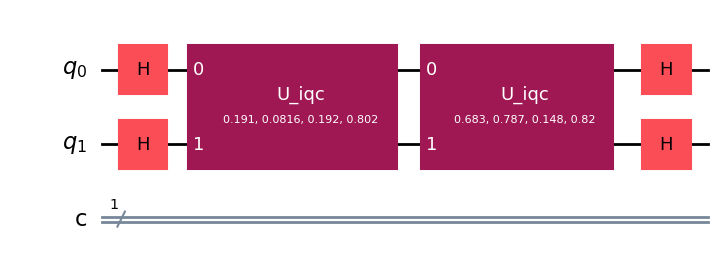

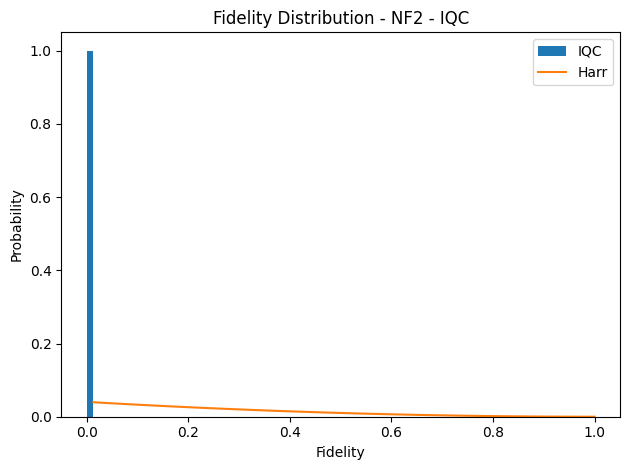

S(P || Q) = 3.232
KL Divergence for NF2 - IQC: 3.232238786943816


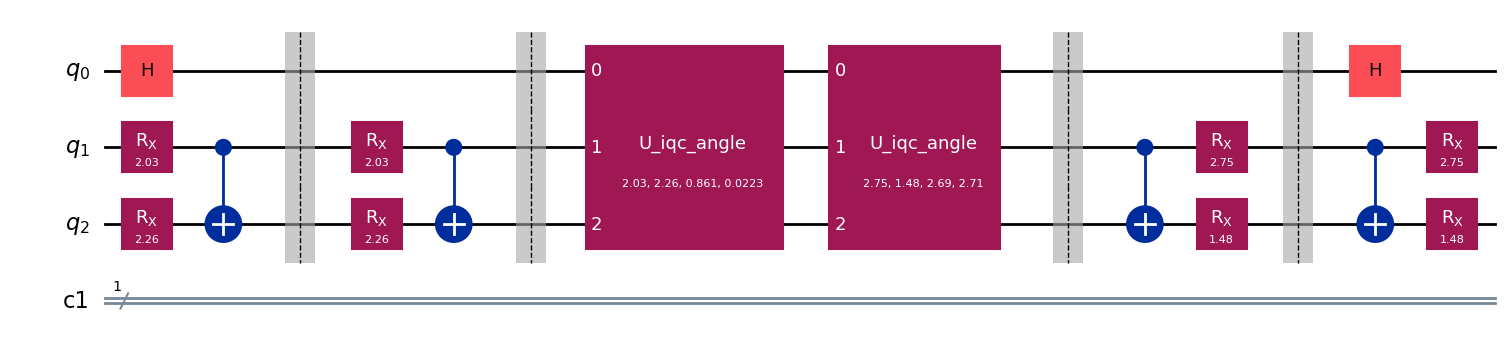

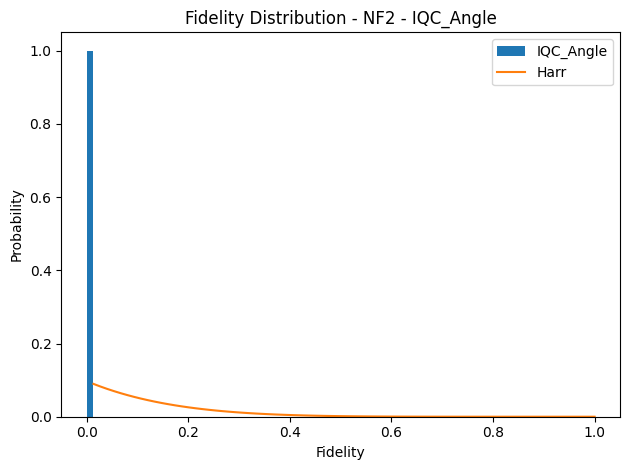

S(P || Q) = 2.411
KL Divergence for NF2 - IQC_Angle: 2.411486697577223


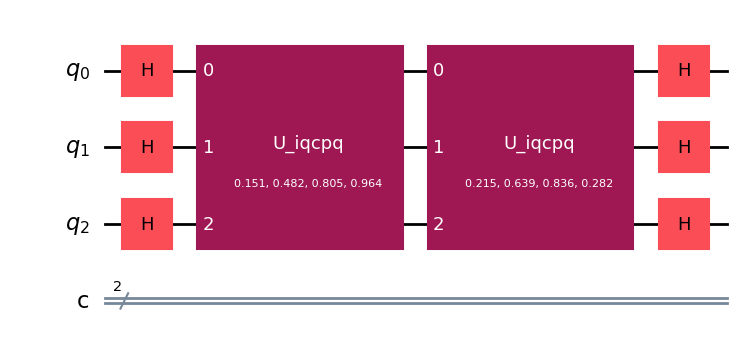

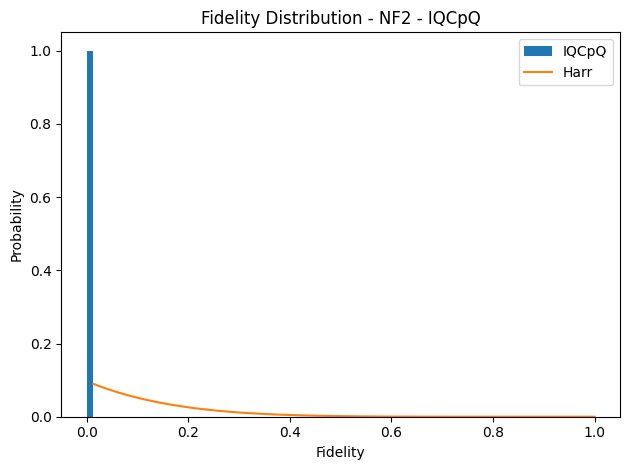

S(P || Q) = 2.411
KL Divergence for NF2 - IQCpQ: 2.411486697577223


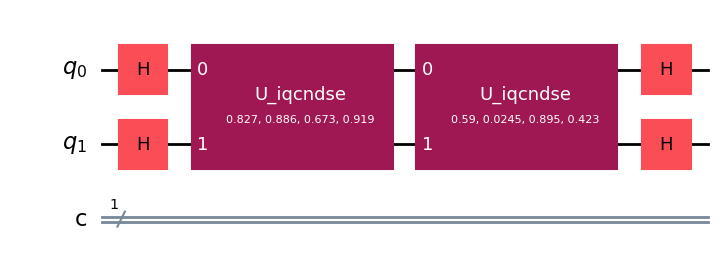

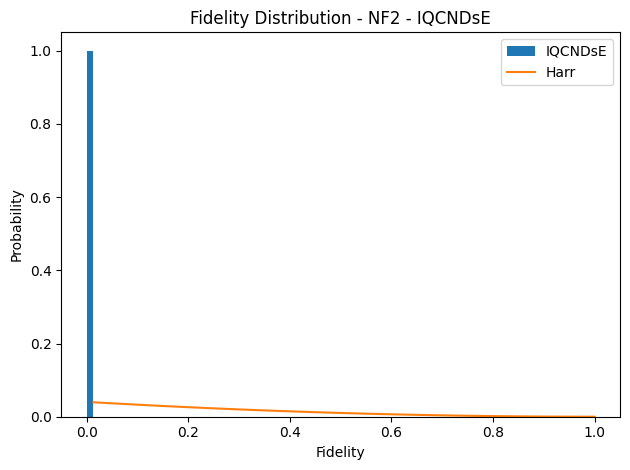

S(P || Q) = 3.232
KL Divergence for NF2 - IQCNDsE: 3.232238786943816


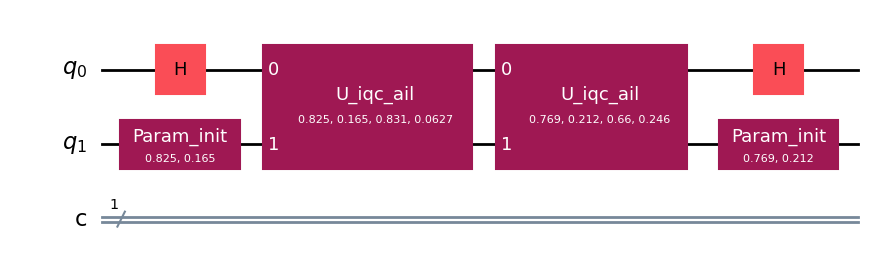

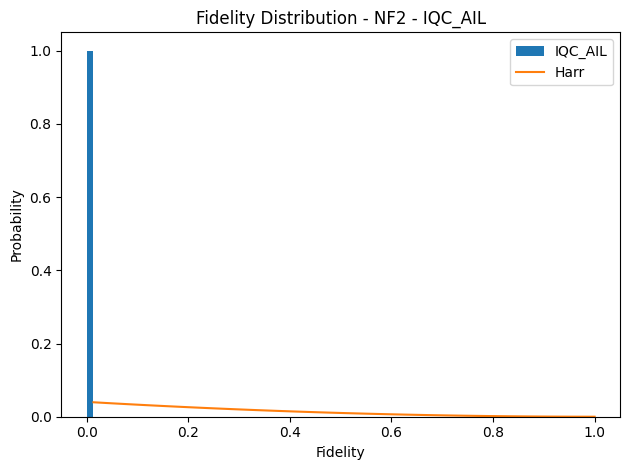

S(P || Q) = 3.232
KL Divergence for NF2 - IQC_AIL: 3.232238786943816

Metrics saved in: NF2_models_expressibilities.csv


In [10]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=2

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

## NF4

In [ ]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=4

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

## NF13

In [78]:
MODELS_LIST=['IQC','IQC_Angle','IQCpQ','IQCNDsE', 'IQC_AIL']
NF=13

kl_div=[]
for model in MODELS_LIST:
    kl_div.append(expressibility(model,NF))
    print(f'KL Divergence for NF{NF} - {model}: {kl_div[-1]}')

data_to_save = {
        'KL Divergence': kl_div,
        'Models': MODELS_LIST
    }

models_expressibilities = pd.DataFrame(data_to_save)
filename = f"NF{NF}" + "_models_expressibilities.csv"
    
# Salvando em CSV
models_expressibilities.to_csv(filename, index=False)
print(f"\nMetrics saved in: {filename}")

TranspilerError: 'HighLevelSynthesis is unable to synthesize "U_IQC"'